# Day 27: Confusion Matrix and Threshold Tuning

**Dataset:** `Customer_Churn_Dataset.csv`

This notebook analyzes classification predictions using a confusion matrix and investigates
how changing the classification threshold affects precision and recall, using the same
customer churn model built on Day 26.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve

# Load the dataset
df = pd.read_csv("../datasets/Customer_Churn_Dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


## 2. Preprocessing and Training the Model

In [2]:
df = df.drop(columns=["CustomerID"])
df = pd.get_dummies(df, columns=["Gender", "Subscription Type", "Contract Length"], drop_first=True)

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_columns = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


**Getting predicted probabilities with `predict_proba()`**

Instead of jumping straight to a 0/1 prediction, this keeps the underlying probability of
churn for every customer, so different thresholds can be tested against it.

In [3]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1 (Churn)

print(y_proba[:10].round(3))

[0.016 0.063 0.088 0.074 0.147 0.019 0.101 0.007 0.092 0.207]


## 3. Confusion Matrix Visualization (Default Threshold = 0.5)

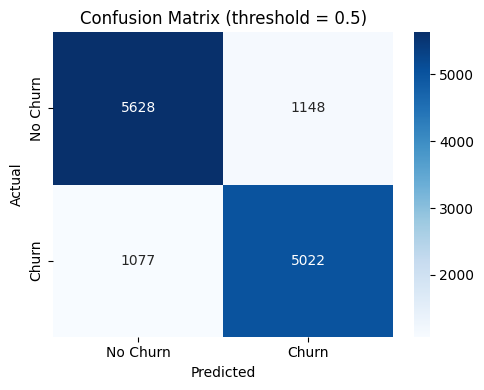

In [4]:
y_pred_default = (y_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

## 4. Results for Multiple Probability Thresholds

The default threshold is 0.5 (predict "Churn" if the probability is 50% or higher), but that
default isn't required — testing several thresholds shows how the trade-off between precision
and recall shifts.

In [5]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for threshold in thresholds_to_test:
    y_pred_t = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })

threshold_results = pd.DataFrame(results)
threshold_results

,threshold,precision,recall,f1,TP,FP,FN,TN
0,0.3,0.728988,0.918675,0.812913,5603,2083,496,4693
1,0.4,0.774479,0.876701,0.822426,5347,1557,752,5219
2,0.5,0.813938,0.823414,0.818649,5022,1148,1077,5628
3,0.6,0.847709,0.749303,0.795474,4570,821,1529,5955
4,0.7,0.877632,0.656173,0.750915,4002,558,2097,6218


## 5. Precision-Recall Comparison

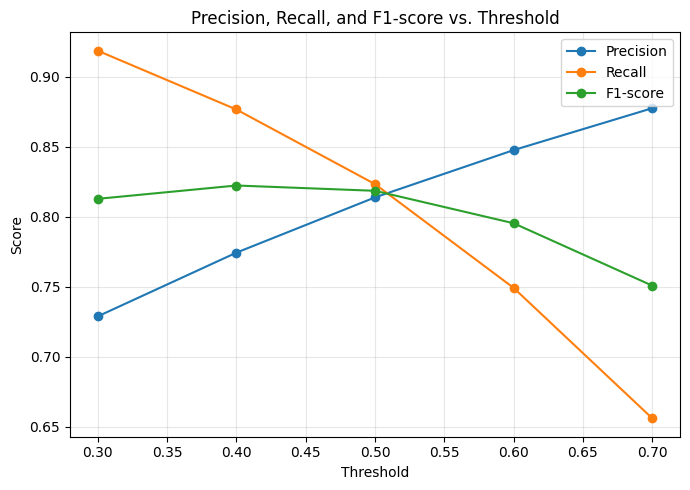

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score vs. Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The full precision-recall curve, using `scikit-learn`'s built-in function**

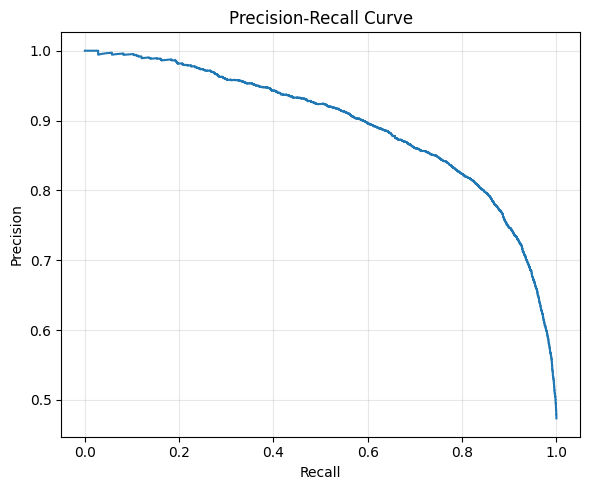

In [7]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** as the threshold increases, **precision goes up** (the model only flags
customers it's more confident about, so fewer of its "Churn" predictions are wrong) while
**recall goes down** (it becomes more conservative, so it misses more actual churners). This
is the fundamental precision-recall trade-off, i.e., you can't usually increase one without giving
up some of the other.

## 6. Recommended Threshold, With Justification

**Recommended threshold: 0.4** (instead of the default 0.5).

In [8]:
recommended_threshold = 0.4
y_pred_recommended = (y_proba >= recommended_threshold).astype(int)

default_row = threshold_results[threshold_results["threshold"] == 0.5].iloc[0]
recommended_row = threshold_results[threshold_results["threshold"] == recommended_threshold].iloc[0]

print("At threshold 0.5 (default):")
print(f"  Precision: {default_row['precision']:.3f}, Recall: {default_row['recall']:.3f}, F1: {default_row['f1']:.3f}")
print(f"  Missed churners (FN): {int(default_row['FN'])}")
print()
print(f"At threshold {recommended_threshold} (recommended):")
print(f"  Precision: {recommended_row['precision']:.3f}, Recall: {recommended_row['recall']:.3f}, F1: {recommended_row['f1']:.3f}")
print(f"  Missed churners (FN): {int(recommended_row['FN'])}")
print()
print(f"Additional churners caught by lowering the threshold: {int(default_row['FN'] - recommended_row['FN'])}")
print(f"Additional false alarms this causes: {int(recommended_row['FP'] - default_row['FP'])}")

At threshold 0.5 (default):
  Precision: 0.814, Recall: 0.823, F1: 0.819
  Missed churners (FN): 1077

At threshold 0.4 (recommended):
  Precision: 0.774, Recall: 0.877, F1: 0.822
  Missed churners (FN): 752

Additional churners caught by lowering the threshold: 325
Additional false alarms this causes: 409


**Justification:** As discussed on Day 26, a False Negative (missing an actual churner)
is typically far more costly than a False Positive (offering retention incentives to a
customer who wasn't going to leave) — a missed churner represents lost future revenue, while a
false alarm just costs a relatively cheap retention offer. Lowering the threshold from 0.5 to
0.4 catches **325 more actual churners** (cutting missed churners from 1,077 down to 752), at
the cost of **409 more false alarms**. Given that the cost of a false alarm is relatively low
compared to losing a customer, this trade-off is worth making. As a bonus, threshold 0.4
doesn't just trade recall for precision blindly — it also has the **highest F1-score of any
threshold tested** (0.822 vs. 0.819 at the default 0.5), so this isn't a case of sacrificing
overall quality for recall; it's a genuine improvement by both measures.

## Outcome

This notebook analyzed a logistic regression churn model's predictions using a confusion
matrix visualization, and tested five different probability thresholds (0.3 through 0.7) to
see how precision, recall, and F1-score shift as the threshold changes. As expected, raising
the threshold increased precision while decreasing recall, and vice versa — the fundamental
precision-recall trade-off, visualized both as a threshold sweep and as a full
precision-recall curve. Based on the business reasoning that a missed churner (False Negative)
is typically costlier than a false retention offer (False Positive), I recommended lowering
the threshold from the default 0.5 to 0.4, which catches 325 more actual churners at the cost
of 409 more false alarms. This is a trade-off justified by the relative costs involved, and one that
also happened to produce the best F1-score of any threshold tested. This showed that the
default 0.5 threshold is just a starting point, not necessarily the best choice for a specific
business problem.